# สำรวจ G1 หยิบของ (Manipulation) — จากเดินสู่การจับ

notebook นี้เป็นคู่กับ `explore_g1_velocity.ipynb` แต่โฟกัสสิ่งที่ **ต่าง**
ออกไปเมื่อเปลี่ยนจากงานเดินเป็นงานหยิบของ ผ่าน task `Mjlab-Lift-Cube-G1`
ที่เราสร้างเอง (ดู `docs/development/g1_manipulation_vla.md`)

**อะไรที่ต่างจาก velocity:**

| ประเด็น | velocity (เดิน) | manipulation (หยิบ) |
|---------|-----------------|---------------------|
| ฐานหุ่น | ลอย (floating, เดินได้) | ยึดสะโพก (fixed, แขนขยับ) |
| DOF | 29 (ทั้งตัว) | 43 (29 + มือ Dex3 14) |
| วัตถุในฉาก | ไม่มี | โต๊ะ + cube |
| คำสั่ง | ความเร็ว twist | ความสูงเป้าหมายที่จะยก cube |
| reward | เดินตามคำสั่ง | เอื้อมถึง → ยก → แม่นยำ (staged) |

แนวคิด MDP เหมือนเดิม (obs → action → reward → termination) แต่เนื้อหา
ในแต่ละส่วนเปลี่ยนไปตามงาน

## 1) โหลด task แล้วสร้าง env

> `wp.config.quiet` ปิด log ของ MuJoCo Warp ตอน compile kernel ให้ output สะอาด

In [1]:
import warp as wp

wp.config.quiet = True

import mujoco
import numpy as np
import torch
from PIL import Image

import mjlab.tasks  # noqa: F401
from mjlab.envs import ManagerBasedRlEnv
from mjlab.tasks.registry import load_env_cfg

device = "cuda" if torch.cuda.is_available() else "cpu"
env_cfg = load_env_cfg("Mjlab-Lift-Cube-G1", play=True)
env_cfg.scene.num_envs = 8
env = ManagerBasedRlEnv(cfg=env_cfg, device=device)
print("device =", device, "| num_envs =", env.num_envs)

Warp DeprecationWarning: warp.config.quiet is deprecated; use warp.config.log_level = warp.LOG_WARNING to suppress the init banner.


Warp 1.14.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/whoami/Library/Caches/warp/1.14.0



+--------------------------------+
|        Base Environment        |
+------------------------+-------+
| Property               | Value |
+------------------------+-------+
| Number of environments | 8     |
| Environment device     | cpu   |
| Environment seed       | None  |
| Physics step-size      | 0.005 |
| Environment step-size  | 0.02  |
+------------------------+-------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
+--------+----------------------------+
+---------------------------------------+
| Active Event Terms in Mode: 'startup' |
+-------+-------------------------------+
| Index | Name                          |
+-------+-------------------------------+
|   0   | fingertip_friction_slide  

## 2) ฉากประกอบด้วยอะไรบ้าง — หุ่น + โต๊ะ + cube

**แนวคิด:** ต่างจาก velocity ที่มีแค่หุ่น งานหยิบต้องมี **วัตถุ** ให้จับและ
**พื้นผิว** ให้วาง. mjlab เก็บทุกอย่างเป็น 'entity' ในฉาก แต่ละ entity มี prefix
ชื่อของตัวเอง (เช่น `robot/...`, `cube/...`) เพื่อกันชื่อชนกัน

In [2]:
print("entities ในฉาก:", list(env.scene.entities.keys()))
print()
robot = env.scene["robot"]
print("หุ่น G1+มือ: จำนวนข้อต่อ =", robot.num_joints, "(29 ตัว + มือ Dex3 14 ตัว)")
print("เป็น fixed base ไหม (สะโพกยึดโลก):", robot.is_fixed_base)

entities ในฉาก: ['terrain', 'robot', 'table', 'cube']

หุ่น G1+มือ: จำนวนข้อต่อ = 43 (29 ตัว + มือ Dex3 14 ตัว)
เป็น fixed base ไหม (สะโพกยึดโลก): True


## 3) มือ Dex3 — 14 ข้อต่อที่เพิ่มเข้ามา

**แนวคิด:** สิ่งที่ทำให้หยิบของได้คือ 'มือ' ที่มีนิ้วขยับได้ เราติด Unitree
Dex3-1 (3 นิ้ว: โป้ง/ชี้/กลาง) สองข้าง = 14 ข้อต่อ. ลองกรองดูเฉพาะข้อต่อมือ

In [3]:
hand_joints = [j for j in robot.joint_names if "hand" in j]
print(f"ข้อต่อมือทั้งหมด {len(hand_joints)} ตัว:")
for j in hand_joints:
  print("  -", j)

ข้อต่อมือทั้งหมด 14 ตัว:
  - left_hand_thumb_0_joint
  - left_hand_thumb_1_joint
  - left_hand_thumb_2_joint
  - left_hand_middle_0_joint
  - left_hand_middle_1_joint
  - left_hand_index_0_joint
  - left_hand_index_1_joint
  - right_hand_thumb_0_joint
  - right_hand_thumb_1_joint
  - right_hand_thumb_2_joint
  - right_hand_middle_0_joint
  - right_hand_middle_1_joint
  - right_hand_index_0_joint
  - right_hand_index_1_joint


## 4) Grasp site — 'จุดจับ' ที่ใช้วัดว่าเอื้อมถึง cube ไหม

**แนวคิด:** เราไม่ได้วัดระยะจากทั้งมือถึง cube (ซับซ้อน) แต่กำหนด **จุดอ้างอิง**
หนึ่งจุดที่ฝ่ามือ เรียก grasp site แล้ววัดระยะจากจุดนี้ถึง cube. reward ใช้
ระยะนี้เป็นตัวชี้ว่า 'เอื้อมใกล้ขึ้นไหม'. มาดูตำแหน่งจริงของ grasp site กับ cube

In [4]:
obs, _ = env.reset()
m = env.sim.mj_model
d = mujoco.MjData(m)
qpos0 = env.sim.data.qpos[0].detach().cpu().numpy()
d.qpos[: len(qpos0)] = qpos0
mujoco.mj_forward(m, d)


def world_pos_site(name):
  sid = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_SITE, name)
  return d.site_xpos[sid].copy()


def world_pos_body(name):
  bid = mujoco.mj_name2id(m, mujoco.mjtObj.mjOBJ_BODY, name)
  return d.xpos[bid].copy()


grasp = world_pos_site("robot/right_grasp_site")
cube = world_pos_body("cube/cube")
print("ตำแหน่ง grasp site (มือขวา):", grasp.round(3))
print("ตำแหน่ง cube            :", cube.round(3))
print(
  "ระยะห่าง                :", float(np.linalg.norm(grasp - cube)).__round__(3), "เมตร"
)

Module reset_data__locals__reset_xfrc_applied_03030511 6442adb load on device 'cpu' took 0.66 ms  (cached)
Module reset_data__locals__reset_M_631075dd 270a798 load on device 'cpu' took 0.57 ms  (cached)
Module reset_data__locals__reset_mocap_6513201c ee8f7ba load on device 'cpu' took 1.03 ms  (cached)
Module reset_data__locals__reset_contact_5c08f689 9d2cde1 load on device 'cpu' took 0.48 ms  (cached)
Module reset_data__locals__reset_sleep_50b990da 5427725 load on device 'cpu' took 1.23 ms  (cached)
Module reset_data__locals__reset_nworld_69a10925 c22681c load on device 'cpu' took 0.28 ms  (cached)
Module mujoco_warp._src.smooth 60df080 load on device 'cpu' took 1.90 ms  (cached)


Module _nxn_broadphase__locals__kernel_df6640ed 8a5d6ba load on device 'cpu' took 0.89 ms  (cached)
Module ccd_kernel_builder__locals__ccd_kernel_a260c781 1986412 load on device 'cpu' took 1.05 ms  (cached)


Module _primitive_narrowphase__locals__primitive_narrowphase_bd42aa16 ebef875 load on device 'cpu' took 1.37 ms  (cached)
Module mujoco_warp._src.constraint 1055a87 load on device 'cpu' took 0.56 ms  (cached)
Module _friction_dof__locals__kernel_196c77d2 ed54ad1 load on device 'cpu' took 1.49 ms  (cached)
Module _limit_slide_hinge__locals__kernel_6e38514e f43752c load on device 'cpu' took 1.81 ms  (cached)
Module _efc_contact_init__locals__kernel_a50a673e 3a315c2 load on device 'cpu' took 0.88 ms  (cached)
Module _efc_contact_jac_sparse__locals__kernel_04af7329 a524580 load on device 'cpu' took 0.85 ms  (cached)
Module _efc_contact_update__locals__kernel_c40b0799 50c07a2 load on device 'cpu' took 0.56 ms  (cached)
Module mujoco_warp._src.sensor 5b546e1 load on device 'cpu' took 0.99 ms  (cached)
Module mujoco_warp._src.forward 70f2f91 load on device 'cpu' took 1.09 ms  (cached)
Module mujoco_warp._src.passive 9ef5a40 load on device 'cpu' took 0.95 ms  (cached)
Module _qfrc_smooth__loca

Module _update_constraint_efc__locals__kernel_4af8f110 fc7fac2 load on device 'cpu' took 1.22 ms  (cached)
Module _update_constraint_init_qfrc_constraint_sparse__locals__kernel_16efb537 0d9a44e load on device 'cpu' took 1.37 ms  (cached)
Module _update_gradient_zero_grad_dot__locals__kernel_cb780630 407be49 load on device 'cpu' took 0.42 ms  (cached)
Module _update_gradient_grad__locals__kernel_0cbf4927 992aea9 load on device 'cpu' took 0.53 ms  (cached)
Module _update_gradient_init_h_sparse__locals__kernel_8d599502 c72ae5a load on device 'cpu' took 0.48 ms  (cached)
Module _JTDAJ_sparse__locals__kernel_6fe61e97 a2b5fff load on device 'cpu' took 0.55 ms  (cached)
Module _update_gradient_cholesky_blocked__locals__kernel_460973b0 45d11a0 load on device 'cpu' took 0.89 ms  (cached)
Module _linesearch_jv_fused_kernel__locals__kernel_55d308c4 0c475d5 load on device 'cpu' took 0.85 ms  (cached)
Module _linesearch_iterative_kernel__locals__kernel_17bdadd0 051e995 load on device 'cpu' took 0.7

**อ่านผล:** ระยะนี้คือสิ่งที่ policy ต้องเรียนรู้ที่จะทำให้เล็กลง (เอื้อมมือ
เข้าหา cube) ก่อนจะยก. ตอน reset cube ถูกสุ่มวางบนโต๊ะในระยะที่แขนเอื้อมถึง

## 5) คำสั่ง (Command) — ยก cube สูงแค่ไหน

**แนวคิด:** velocity สั่งด้วย 'ความเร็ว' แต่งานนี้สั่งด้วย 'ความสูงเป้าหมาย'
ที่อยากให้ cube ถูกยกขึ้นไป. CommandManager สุ่มเป้าหมายใหม่เป็นระยะๆ เพื่อให้
policy เรียนรู้ที่จะยกได้หลายระดับ

In [5]:
print("command terms:", list(env.command_manager.active_terms))
cmd = env.command_manager.get_term("lift_height")
print("ประเภท command:", type(cmd).__name__)

command terms: ['lift_height']
ประเภท command: LiftingCommand


## 6) Reward แบบ staged — เอื้อมถึง → ยก → แม่นยำ

**แนวคิด:** งานหยิบยากกว่าเดินเพราะต้องทำหลายขั้นตามลำดับ. ถ้าให้ reward
แค่ตอน 'ยกสำเร็จ' policy จะหา reward ไม่เจอเลยตอนแรก (sparse). เราจึงแบ่ง
reward เป็น **ขั้น (staged)**: ได้คะแนนเพิ่มเรื่อยๆ ตั้งแต่เอื้อมเข้าใกล้ →
แตะ cube → ยกขึ้น → ยกได้ตรงความสูงเป้าหมาย. แบบนี้ policy มี 'เส้นทาง'
ให้ไต่ทีละขั้น

In [6]:
print("reward terms และน้ำหนัก:")
for name, term_cfg in env_cfg.rewards.items():
  print(f"  {name:20s} weight = {term_cfg.weight:+.3f}")

reward terms และน้ำหนัก:
  lift                 weight = +1.000
  lift_precise         weight = +1.000
  action_rate_l2       weight = -0.010
  joint_pos_limits     weight = -10.000
  joint_vel_hinge      weight = -0.010


**อ่านผล:** `lift` = reward หลักแบบ staged (เอื้อม→ยก), `lift_precise` =
โบนัสเมื่อยกได้ตรงเป้า, ส่วน `action_rate_l2`/`joint_pos_limits`/
`joint_vel_hinge` เป็นโทษ (weight ลบ) กันไม่ให้ขยับกระตุกหรือฝืนข้อต่อ

## 7) ขับ env ดู reward ของ zero vs random

เหมือน notebook velocity: zero action = แขนอยู่ท่าเริ่มต้น, random = ขยับมั่ว

In [7]:
def rollout(action_fn, steps=40):
  env.reset()
  total = torch.zeros(env.num_envs, device=device)
  for _ in range(steps):
    obs, reward, term, trunc, info = env.step(action_fn())
    total += reward
  return (total / steps).mean().item()


dim = env.action_manager.total_action_dim
print("มิติ action (43 = 29 ตัว + มือ 14):", dim)
z = rollout(lambda: torch.zeros(env.num_envs, dim, device=device))
r = rollout(lambda: torch.randn(env.num_envs, dim, device=device) * 0.5)
print(f"zero action   : reward/step = {z:+.3f}")
print(f"random action : reward/step = {r:+.3f}")

มิติ action (43 = 29 ตัว + มือ 14): 43


Module mujoco_warp._src.derivative 761668c load on device 'cpu' took 1.82 ms  (cached)


Module _next_time_builder__locals___next_time_95ad6d7a e26b00c load on device 'cpu' took 0.73 ms  (cached)


zero action   : reward/step = -0.134
random action : reward/step = -3.620


## 8) เรนเดอร์ฉาก — เห็นหุ่นเอื้อมเหนือโต๊ะ

เรนเดอร์จากมุมด้านข้างเพื่อเห็นหุ่น G1 (สะโพกยึด) เอื้อมมือเหนือโต๊ะที่มี cube

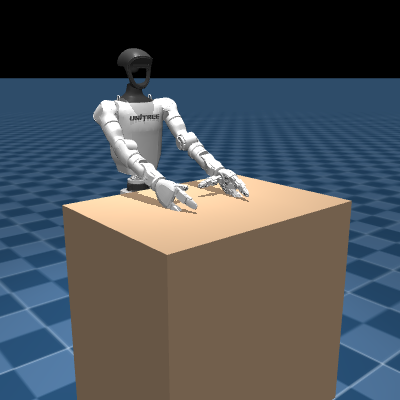

In [8]:
env.reset()
qpos0 = env.sim.data.qpos[0].detach().cpu().numpy()
d.qpos[: len(qpos0)] = qpos0
mujoco.mj_forward(m, d)

renderer = mujoco.Renderer(m, height=400, width=400)
cam = mujoco.MjvCamera()
cam.lookat[:] = [0.4, 0, 0.8]
cam.distance = 1.7
cam.azimuth = 140
cam.elevation = -15
renderer.update_scene(d, cam)
Image.fromarray(renderer.render())

## 9) จากหยิบ สู่ Vision — ให้ policy 'มองเห็น' cube

**แนวคิด:** task ข้างบนบอกตำแหน่ง cube ให้ policy ตรงๆ (privileged state)
แต่หุ่นจริงไม่มีพลังวิเศษรู้พิกัด — ต้อง **มองจากกล้อง**. เรามี variant
`Mjlab-Lift-Cube-G1-Rgb` ที่ติดกล้องหัวแล้วให้ policy ดูภาพแทนพิกัด

มาดูว่า observation ต่างกันอย่างไร: variant vision มี group `camera` เพิ่ม และ
actor **ไม่เห็น** พิกัด cube แล้ว (เห็นแต่ภาพ)

In [9]:
vis_cfg = load_env_cfg("Mjlab-Lift-Cube-G1-Rgb", play=True)
vis_cfg.scene.num_envs = 2
vis_env = ManagerBasedRlEnv(cfg=vis_cfg, device=device)
vobs, _ = vis_env.reset()
print("observation groups (vision):", list(vobs.keys()))
for k, v in vobs.items():
  print(f"  {k:8s}: shape = {tuple(v.shape)}")

Module mujoco_warp._src.render_util d9a3176 load on device 'cpu' took 1.36 ms  (cached)
Module mujoco_warp._src.io 056e107 load on device 'cpu' took 1.41 ms  (cached)
Module mujoco_warp._src.bvh fb7c74a load on device 'cpu' took 0.81 ms  (cached)

+--------------------------------+
|        Base Environment        |
+------------------------+-------+
| Property               | Value |
+------------------------+-------+
| Number of environments | 2     |
| Environment device     | cpu   |
| Environment seed       | None  |
| Physics step-size      | 0.005 |
| Environment step-size  | 0.02  |
+------------------------+-------+

[INFO] <EventManager> contains 2 active terms.
+-------------------------------------+
| Active Event Terms in Mode: 'reset' |
+--------+----------------------------+
| Index  | Name                       |
+--------+----------------------------+
|   0    | reset_base                 |
|   1    | reset_robot_joints         |
|   2    | cube_color                 |

Module render__locals___render_megakernel_6d576b6e a771224 load on device 'cpu' took 2.55 ms  (cached)
Module mjlab.sensor.sensor_context f8471b3 load on device 'cpu' took 0.96 ms  (cached)
observation groups (vision): ['actor', 'critic', 'camera']
  actor   : shape = (2, 132)
  critic  : shape = (2, 135)
  camera  : shape = (2, 3, 64, 64)


รูปทรง camera obs (C,H,W): (3, 64, 64)


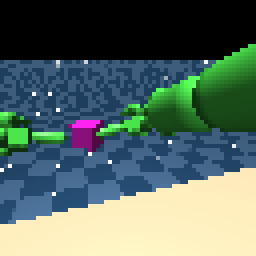

In [10]:
# ภาพที่ policy เห็นจริง (64x64) จากกล้องหัว G1
cam_obs = vobs["camera"][0].detach().cpu().numpy()  # (C, H, W)
img = np.transpose(cam_obs, (1, 2, 0))  # -> (H, W, C)
img = (img * 255).clip(0, 255).astype(np.uint8)
print("รูปทรง camera obs (C,H,W):", cam_obs.shape)
Image.fromarray(img).resize((256, 256), Image.NEAREST)

## 10) สรุป

- งานหยิบใช้ **MDP** โครงเดียวกับเดิน แต่: ฐานยึด, +มือ 14 DOF, +โต๊ะ/cube,
  คำสั่ง = ความสูงเป้าหมาย, reward = **staged** (เอื้อม→ยก→แม่น)
- **grasp site** คือกลไกง่ายๆ ที่เปลี่ยนปัญหา 'จับของ' เป็น 'ทำให้ระยะจุดหนึ่ง
  ถึง cube เล็กลง' — จูน reward ได้ง่ายขึ้นมาก
- **staged reward** แก้ปัญหา reward เบาบาง (sparse) ด้วยการให้คะแนนทีละขั้น
- variant **vision** เปลี่ยนจากรู้พิกัด cube เป็นมองจากกล้อง — เข้าใกล้หุ่นจริง
  และเป็นบันไดสู่ **VLA** (มองภาพ+ฟังคำสั่งภาษา→ลงมือทำ)

**ขั้นถัดไปของโปรเจค:** ใส่ขาให้เดินไปหยิบ (loco-manipulation) แล้ว distill
เป็น VLA — ดู roadmap ใน `docs/development/g1_manipulation_vla.md`